In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import math

# Pour l'affichage des nombres
np.set_printoptions(precision=4, suppress=False)


In [3]:
# === CONFIG DATASET ===
# -> Adapter UNIQUEMENT ces chemins à ta machine

dataset_name = "ISIC_2016"

# Dossier contenant les images dermoscopiques (.jpg, .jpeg ou .png)
images_dir = "dataset_ISIC/ISBI2016_ISIC_Part1_Training_Data" 

# Dossier contenant les masques binaires correspondants (.png en général)
masks_dir = "dataset_ISIC/ISBI2016_ISIC_Part1_Training_GroundTruth" 

# Extensions autorisées pour les images d'entrée
image_extension = ".jpg" # Toutes les images sont en jpg

# Extension des masques (à adapter si besoin)
mask_extension = ".png" # Tous les masks sont png


In [4]:
def summary_stats(values):
    """Retourne min, max, moyenne, médiane, etc. pour une liste de nombres."""
    arr = np.asarray(values, dtype=float)
    return {
        "count": int(arr.size),
        "min": float(np.min(arr)),
        "q1": float(np.percentile(arr, 25)),
        "median": float(np.median(arr)),
        "q3": float(np.percentile(arr, 75)),
        "max": float(np.max(arr)),
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
    }

def load_image(path):
    """Charge une image et la renvoie sous forme de np.array."""
    img = Image.open(path)
    return np.array(img)

def binarize_mask(mask_arr):
    """Convertit un masque (0/255 ou RGB) en masque binaire 0/1. Si c'est un masque avec nuances de gris ça le convertit aussi"""
    if mask_arr.ndim == 3:
        mask_arr = mask_arr[..., 0]  # on garde que le premier canal, on s'en fou du reste puisque si c'est blanc alors ca serq (255, 255, 255) sinon noir (0,0,0) et le gris est considéré comme blanc
    return (mask_arr > 0).astype(np.uint8)

In [5]:
# === Comptage des images et des masques ===
print(os.getcwd())
# Liste des fichiers images
images = os.listdir(images_dir)

# Liste des fichiers masques
masks = os.listdir(masks_dir)

print(f"Nombre d'images trouvées  : {len(images)}")
print(f"Nombre de masques trouvés : {len(masks)}")

/Users/sfarmehdi/Desktop/bureau/UNIV/COURS_2A/S1/statapp
Nombre d'images trouvées  : 900
Nombre de masques trouvés : 900


In [6]:
# On remarque que les numéros des fichiers ne se suivent pas nécessairement, on va vérifier que la suite des numéros est la même dans les deux dossiers (images et masks)
images_num = sorted([f.replace("ISIC_", "").replace(".jpg", "") for f in images])
masks_num = sorted([f.replace("ISIC_", "").replace("_Segmentation", "").replace(".png", "") for f in masks])

if masks_num == images_num : 
    print(f"Les deux vecteurs sont identiques. Toute les images du dataset on un masque correspondant de même numéro que l'image")
print("Les deux vecteurs ne sont pas identiques")


Les deux vecteurs sont identiques. Toute les images du dataset on un masque correspondant de même numéro que l'image
Les deux vecteurs ne sont pas identiques


In [7]:
# os.listdir(images_dir) et os.listdir(masks_dir) sont des vecteurs non ordonnés
# on va avoir besoin des file path pour pouvoir load les images

img_paths = sorted([os.path.join(images_dir, f) for f in images])
masks_paths = sorted([os.path.join(masks_dir, f) for f in masks])
N = len(images)


In [8]:
# Vérification du format du premier masque
mask = load_image(masks_paths[0])
print(f"Dimensions: {mask.shape}")
print(f"Valeurs uniques: {np.unique(mask)}")

Dimensions: (767, 1022)
Valeurs uniques: [  0 255]


In [9]:
# On a donc nos masks qui ne sont pas binariser, il faut donc le faire afin de standardiser nos données

In [10]:
# === Calcul des stats de base par image (géométrie + taille du masque) ===

widths, heights, img_areas = [], [], []
mask_areas, mask_ratios = [], []


for f in range(N):

    # Charge image et masque
    img = load_image(img_paths[f])
    mask = load_image(masks_paths[f])

    # Dimensions image
    h, w = img.shape[:2]
    widths.append(w)
    heights.append(h)
    img_area = w * h
    img_areas.append(img_area)

    # Binarise masque et calcule aire
    mask_bin = binarize_mask(mask)
    m_area = int(mask_bin.sum())
    mask_areas.append(m_area)
    mask_ratios.append(m_area / img_area if img_area > 0 else 0.0)

print("\n--- Géométrie des images ---")
print("Largeur (px) :", summary_stats(widths))
print("Hauteur (px) :", summary_stats(heights))
print("Aire (px²)   :", summary_stats(img_areas))

print("\n--- Taille des lésions (masques) ---")
print("Aire masque (px)        :", summary_stats(mask_areas))
print("Ratio masque / image    :", summary_stats(mask_ratios))



--- Géométrie des images ---
Largeur (px) : {'count': 900, 'min': 576.0, 'q1': 1024.0, 'median': 1024.0, 'q3': 2048.0, 'max': 4288.0, 'mean': 1555.9788888888888, 'std': 991.9894660052757}
Hauteur (px) : {'count': 900, 'min': 542.0, 'q1': 768.0, 'median': 768.0, 'q3': 1536.0, 'max': 2848.0, 'mean': 1133.0655555555556, 'std': 656.2564227260073}
Aire (px²)   : {'count': 900, 'min': 384314.0, 'q1': 786432.0, 'median': 786432.0, 'q3': 3145728.0, 'max': 12212224.0, 'mean': 2409333.672222222, 'std': 3141496.663418297}

--- Taille des lésions (masques) ---
Aire masque (px)        : {'count': 900, 'min': 9087.0, 'q1': 126342.0, 'median': 274132.5, 'q3': 506772.0, 'max': 5989020.0, 'mean': 431723.3288888889, 'std': 556842.8565061627}
Ratio masque / image    : {'count': 900, 'min': 0.011554718017578125, 'q1': 0.10304959615071614, 'median': 0.2134946110857452, 'q3': 0.3808212570892079, 'max': 0.9954388936360677, 'mean': 0.2708734778598123, 'std': 0.21407966646890064}


In [11]:
idx_min, idx_max = np.argmin(mask_ratios), np.argmax(mask_ratios)
print(f"Ratio MIN: {images[idx_min]}, {masks[idx_min]}")
print(f"Ratio MAX: {images[idx_max]}, {masks[idx_max]}")

Ratio MIN: ISIC_0000063.jpg, ISIC_0010439_Segmentation.png
Ratio MAX: ISIC_0007087.jpg, ISIC_0010213_Segmentation.png


In [ ]:
# === Nombre de composantes connexes par masque ===

num_components = []

for f in range(N):

    # Charge le masque
    mask = load_image(masks_paths[f])
    mask_bin = binarize_mask(mask)

    # Chaque "blob" de 1 dans le masque reçoit un label 1, 2, 3, ...
    labeled = label(mask_bin, connectivity=1)

    # Nombre de composantes = max des labels (0 = fond)
    n_comp = int(labeled.max())
    num_components.append(n_comp)

print("\n--- Nombre de composantes connexes par image ---")
print(summary_stats(num_components))


In [ ]:
# On remarque donc qu'on a des lesions dans toutes les images et que toutes les images mettent en avant une segmentation avec une unique lesion (sauf quelques outliers)
outliers = [(img_paths[i], masks_paths[i]) for i in range (N) if num_components[i] >= 2]
print(outliers[0])
print(f"On a {len(outliers)} outliers")

('dataset_ISIC/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000063.jpg', 'dataset_ISIC/ISBI2016_ISIC_Part1_Training_GroundTruth/ISIC_0000063_Segmentation.png')
On a 6 outliers


In [ ]:
# En regardant les outliers on remarque que le mask ne met pas en avant une seconde lesion mais plutot classifie du bruit comme du signal

In [ ]:
# === Répartition des tailles de lésions (en % de la surface de l'image) ===

# mask_ratios est une liste de valeurs entre 0 et 1 -> on passe en pourcentage
mask_ratios_pct = [r * 100 for r in mask_ratios]

bins = {
    "< 1%": 0,
    "1–5%": 0,
    "5–10%": 0,
    "> 10%": 0,
}

for r in mask_ratios_pct:
    if r < 1:
        bins["< 1%"] += 1
    elif r < 5:
        bins["1–5%"] += 1
    elif r < 10:
        bins["5–10%"] += 1
    else:
        bins["> 10%"] += 1

print("\n--- Répartition des tailles de lésions (en % de l'image) ---")
total = len(mask_ratios_pct)
for k, v in bins.items():
    pct = 100 * v / total if total > 0 else 0.0
    print(f"{k:6} : {v:4d} images ({pct:5.1f}%)")

print("\n--- Stats détaillées sur la taille des lésions (en %) ---")
print(summary_stats(mask_ratios_pct))



--- Répartition des tailles de lésions (en % de l'image) ---
< 1%   :    0 images (  0.0%)
1–5%   :   73 images (  8.1%)
5–10%  :  144 images ( 16.0%)
> 10%  :  683 images ( 75.9%)

--- Stats détaillées sur la taille des lésions (en %) ---
{'count': 900, 'min': 1.1554718017578125, 'q1': 10.304959615071613, 'median': 21.349461108574516, 'q3': 38.082125708920785, 'max': 99.54388936360678, 'mean': 27.087347785981226, 'std': 21.407966646890063}


In [ ]:
# Variation des taille des images

# Moyenne des lesions dans l'image

# volume des données

## Visualisation de la taille relative des lésions
La distribution suivante complète les statistiques textuelles en montrant comment se répartit la part occupée par la lésion dans l'image.

In [ ]:
# === Position des lésions principales (centroïde + distance au centre) ===

centroid_x_norm = []   # x normalisé dans [0,1]
centroid_y_norm = []   # y normalisé dans [0,1]
centroid_dist_px = []  # distance euclidienne au centre (en pixels)

for f in range(N):

    # Charge masque et binarise
    mask = load_image(masks_paths[f])
    mask_bin = binarize_mask(mask)

    h, w = mask_bin.shape[:2]

    labeled = label(mask_bin, connectivity=1)
    props = regionprops(labeled)

    # Si pas de lésion (au cas où), on skip
    if len(props) == 0:
        continue

    # On prend la plus grande composante comme "lésion principale"
    main_region = max(props, key=lambda r: r.area)

    cy, cx = main_region.centroid  # (row, col) = (y, x) en pixels

    # Normalisation dans [0,1] (0 = bord haut/gauche, 1 = bord bas/droit)
    cx_norm = cx / w
    cy_norm = cy / h
    centroid_x_norm.append(cx_norm)
    centroid_y_norm.append(cy_norm)

    # Distance au centre de l'image (en pixels)
    center_x = w / 2.0
    center_y = h / 2.0
    dist = math.sqrt((cx - center_x)**2 + (cy - center_y)**2)
    centroid_dist_px.append(dist)

# === Description des centroïdes (position normalisée + distance au centre) ===

stats_cx = summary_stats(centroid_x_norm)
stats_cy = summary_stats(centroid_y_norm)
stats_dist = summary_stats(centroid_dist_px)

print("\n--- Position des centroïdes (coordonnées normalisées dans [0, 1]) ---")
rows_pos = {
    "x_centroid_norm": stats_cx,
    "y_centroid_norm": stats_cy,
}
for k, v in rows_pos.items():
    print(f"{k:17} : mean={v['mean']:.3f}, median={v['median']:.3f}, "
          f"min={v['min']:.3f}, max={v['max']:.3f}")

print("\n--- Distance centroïde - centre de l'image (en pixels) ---")
rows_dist = {
    "dist_centroid_center_px": stats_dist,
}
for k, v in rows_dist.items():
    print(f"{k:24} : mean={v['mean']:.2f}, median={v['median']:.2f}, "
          f"min={v['min']:.2f}, max={v['max']:.2f}")





--- Position des centroïdes (coordonnées normalisées dans [0, 1]) ---
x_centroid_norm   : mean=0.484, median=0.490, min=0.195, max=0.807
y_centroid_norm   : mean=0.499, median=0.501, min=0.237, max=0.690

--- Distance centroïde - centre de l'image (en pixels) ---
dist_centroid_center_px  : mean=109.50, median=52.05, min=1.98, max=1239.19


In [ ]:
# === Statistiques d'intensité (R, G, B, niveau de gris) ===

mean_R, mean_G, mean_B = [], [], []
mean_gray = []

for f in range(N):

    img = load_image(img_paths[f])

    # Si image déjà en niveaux de gris (2D), on la duplique en pseudo-RGB
    if img.ndim == 2:
        img_rgb = np.stack([img, img, img], axis=-1)
    else:
        img_rgb = img[..., :3]  # on ne garde que les 3 premiers canaux au cas où

    r = img_rgb[..., 0].astype(float)
    g = img_rgb[..., 1].astype(float)
    b = img_rgb[..., 2].astype(float)

    mean_R.append(r.mean())
    mean_G.append(g.mean())
    mean_B.append(b.mean())


print("\n--- Intensité moyenne par canal (0-255) ---")
print("R :", summary_stats(mean_R))
print("G :", summary_stats(mean_G))
print("B :", summary_stats(mean_B))



--- Intensité moyenne par canal (0-255) ---
R : {'count': 900, 'min': 77.38737360636394, 'q1': 164.3872344730933, 'median': 182.95896134663283, 'q3': 203.67622717221576, 'max': 246.66698455810547, 'mean': 184.57861221373895, 'std': 28.401997768638154}
G : {'count': 900, 'min': 63.6176300159351, 'q1': 140.9453256072451, 'median': 154.14703717643042, 'q3': 171.8162088394165, 'max': 232.36249160766602, 'mean': 157.7543436411931, 'std': 25.401908066524474}
B : {'count': 900, 'min': 52.735864388671594, 'q1': 126.70447277472982, 'median': 142.7588827939781, 'q3': 161.50894571798568, 'max': 230.7533452192206, 'mean': 144.63558500355956, 'std': 26.865242687242088}

--- Intensité moyenne en niveaux de gris (0-255) ---
Gray : {'count': 900, 'min': 75.56454070790608, 'q1': 147.57588599554697, 'median': 161.98941349193325, 'q3': 177.67697198896053, 'max': 233.15361349868772, 'mean': 164.27926145969408, 'std': 24.56360970232809}


In [ ]:
# === Contraste lésion vs fond (niveaux de gris) ===

mean_lesion = []
mean_background = []
diff_lesion_bg = []       # mean_lesion - mean_background
abs_diff_lesion_bg = []   # |mean_lesion - mean_background|
sign_lesion_darker = []   # +1 si lésion plus sombre, -1 si plus claire

for f in range(N):

    img = load_image(img_paths[f])
    mask = load_image(masks_paths[f])
    mask_bin = binarize_mask(mask)

    # image -> niveaux de gris
    if img.ndim == 2:
        gray = img.astype(float)
    else:
        img_rgb = img[..., :3].astype(float)
        r = img_rgb[..., 0]
        g = img_rgb[..., 1]
        b = img_rgb[..., 2]
        gray = 0.299 * r + 0.587 * g + 0.114 * b

    les_pix = gray[mask_bin == 1]
    bg_pix  = gray[mask_bin == 0]

    # sécurité : si jamais masque vide (normalement non)
    if les_pix.size == 0 or bg_pix.size == 0:
        continue

    m_les = float(les_pix.mean())
    m_bg  = float(bg_pix.mean())
    d     = m_les - m_bg

    mean_lesion.append(m_les)
    mean_background.append(m_bg)
    diff_lesion_bg.append(d)
    abs_diff_lesion_bg.append(abs(d))
    sign_lesion_darker.append(1 if d < 0 else -1)

stats_m_les = summary_stats(mean_lesion)
stats_m_bg  = summary_stats(mean_background)
stats_diff  = summary_stats(diff_lesion_bg)
stats_abs   = summary_stats(abs_diff_lesion_bg)

n = len(diff_lesion_bg)
n_darker  = sum(1 for s in sign_lesion_darker if s == 1)
n_brighter = sum(1 for s in sign_lesion_darker if s == -1)

print("\n--- Intensité moyenne lésion vs fond (niveaux de gris, 0-255) ---")
print(f"mean_lesion    : mean={stats_m_les['mean']:.2f}, "
      f"median={stats_m_les['median']:.2f}, "
      f"min={stats_m_les['min']:.2f}, max={stats_m_les['max']:.2f}")
print(f"mean_background: mean={stats_m_bg['mean']:.2f}, "
      f"median={stats_m_bg['median']:.2f}, "
      f"min={stats_m_bg['min']:.2f}, max={stats_m_bg['max']:.2f}")

print("\n--- Différence lésion - fond (gris) ---")
print(f"diff (lesion - background)  : mean={stats_diff['mean']:.2f}, "
      f"median={stats_diff['median']:.2f}, "
      f"min={stats_diff['min']:.2f}, max={stats_diff['max']:.2f}")
print(f"|diff|                       : mean={stats_abs['mean']:.2f}, "
      f"median={stats_abs['median']:.2f}, "
      f"min={stats_abs['min']:.2f}, max={stats_abs['max']:.2f}")

print("\n--- Signe du contraste ---")
print(f"Lésions plus sombres que le fond : {n_darker:4d} images ({100*n_darker/n:5.1f}%)")
print(f"Lésions plus claires que le fond : {n_brighter:4d} images ({100*n_brighter/n:5.1f}%)")



--- Intensité moyenne lésion vs fond (niveaux de gris, 0-255) ---
mean_lesion    : mean=132.23, median=130.85, min=47.93, max=215.89
mean_background: mean=176.26, median=173.69, min=38.48, max=248.36

--- Différence lésion - fond (gris) ---
diff (lesion - background)  : mean=-44.03, median=-41.03, min=-167.65, max=110.00
|diff|                       : mean=45.69, median=41.65, min=0.01, max=167.65

--- Signe du contraste ---
Lésions plus sombres que le fond :  865 images ( 96.1%)
Lésions plus claires que le fond :   35 images (  3.9%)


In [ ]:
# Le fait que plus de 96.1% des images ont leur lésions plus sombres que le fond indique un risque que le modèle sur apprend sur le niveau d'intensité 

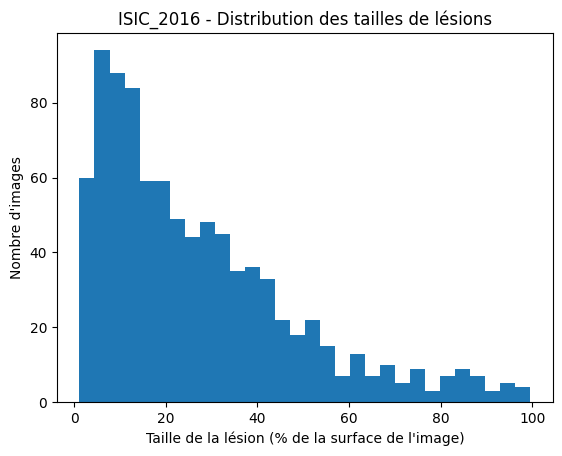

In [ ]:
plt.figure()
plt.hist(mask_ratios_pct, bins=30)
plt.xlabel("Taille de la lésion (% de la surface de l'image)")
plt.ylabel("Nombre d'images")
plt.title(f"{dataset_name} - Distribution des tailles de lésions")
plt.show()


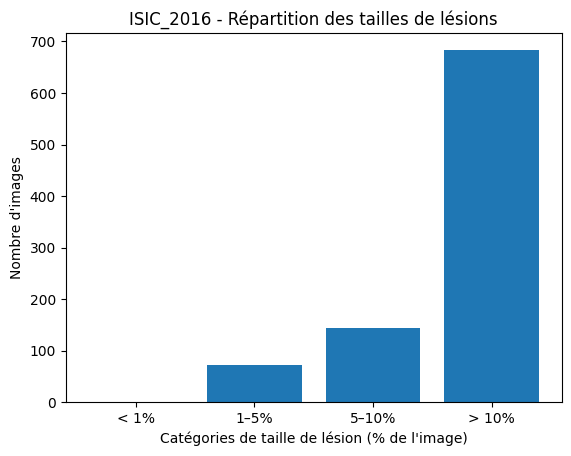

In [ ]:
labels = list(bins.keys())
values = [bins[k] for k in labels]

plt.figure()
plt.bar(labels, values)
plt.xlabel("Catégories de taille de lésion (% de l'image)")
plt.ylabel("Nombre d'images")
plt.title(f"{dataset_name} - Répartition des tailles de lésions")
plt.show()



--- Vérif centroïdes ---
Nb centroïdes calculés : 900


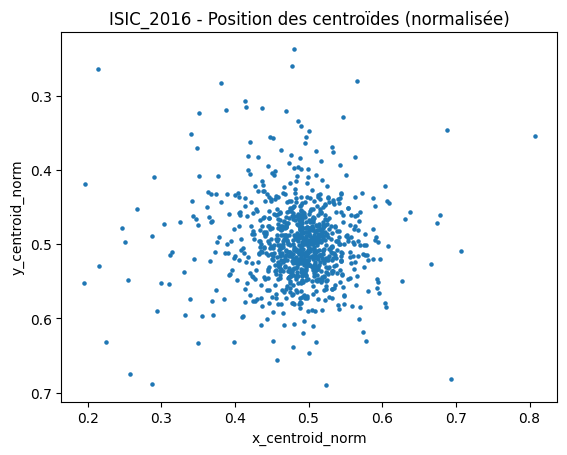

In [ ]:
from skimage.measure import label, regionprops
import math

# === Position des lésions principales (centroïde + distance au centre) ===

centroid_x_norm = []
centroid_y_norm = []
centroid_dist_px = []

for f in range(N):

    mask = load_image(masks_paths[f])
    mask_bin = binarize_mask(mask)

    h, w = mask_bin.shape[:2]

    labeled = label(mask_bin, connectivity=1)
    props = regionprops(labeled)

    # Si pas de lésion (au cas où), on skip
    if len(props) == 0:
        continue

    # Lésion principale = plus grande composante
    main_region = max(props, key=lambda r: r.area)

    cy, cx = main_region.centroid  # (row, col) = (y, x)

    # Normalisation dans [0,1]
    cx_norm = cx / w
    cy_norm = cy / h
    centroid_x_norm.append(cx_norm)
    centroid_y_norm.append(cy_norm)

    # Distance au centre de l'image
    center_x = w / 2.0
    center_y = h / 2.0
    dist = math.sqrt((cx - center_x)**2 + (cy - center_y)**2)
    centroid_dist_px.append(dist)

print("\n--- Vérif centroïdes ---")
print("Nb centroïdes calculés :", len(centroid_x_norm))

plt.figure()
plt.scatter(centroid_x_norm, centroid_y_norm, s=5)
plt.xlabel("x_centroid_norm")
plt.ylabel("y_centroid_norm")
plt.title(f"{dataset_name} - Position des centroïdes (normalisée)")
plt.gca().invert_yaxis()  # optionnel : pour avoir (0,0) en haut à gauche comme l'image
plt.show()


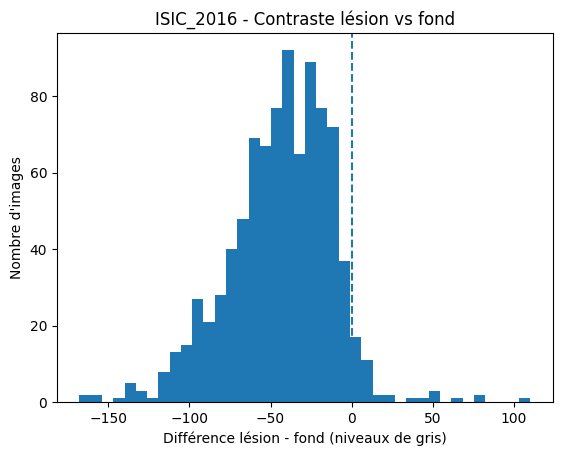

In [ ]:
plt.figure()
plt.hist(diff_lesion_bg, bins=40)
plt.xlabel("Différence lésion - fond (niveaux de gris)")
plt.ylabel("Nombre d'images")
plt.title(f"{dataset_name} - Contraste lésion vs fond")
plt.axvline(0, linestyle="--")  # séparation lésion plus sombre / plus claire
plt.show()
